In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
linear = pd.read_csv("/common/home/lh811/Documents/ML_Pricing/data/linear_models.csv")
tree = pd.read_csv("/common/home/lh811/Documents/ML_Pricing/data/tree_models.csv")

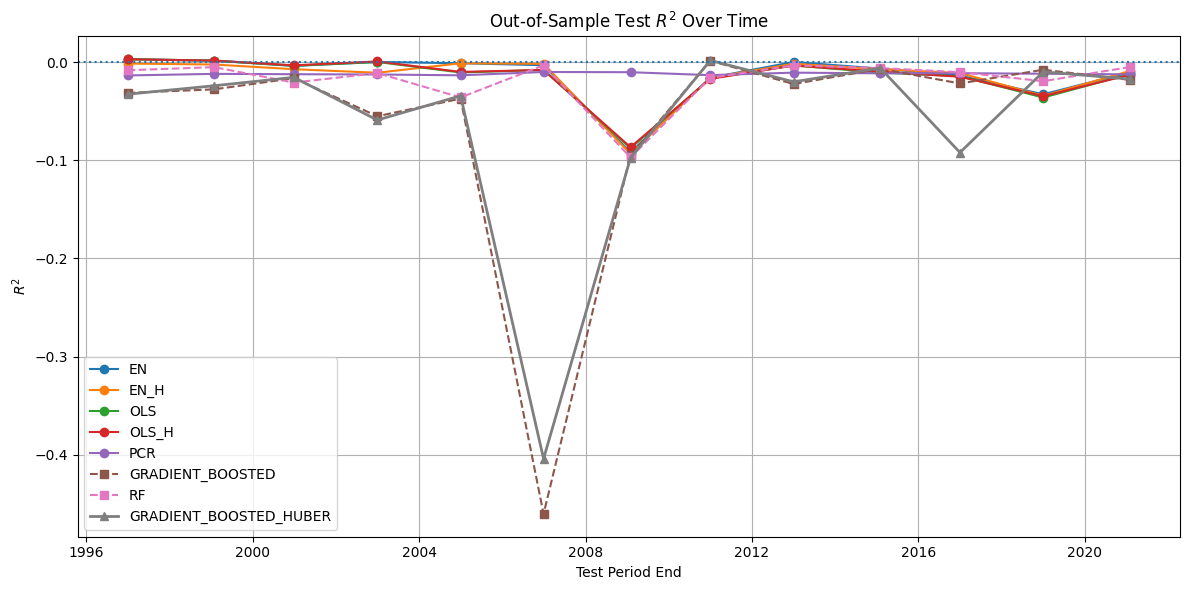

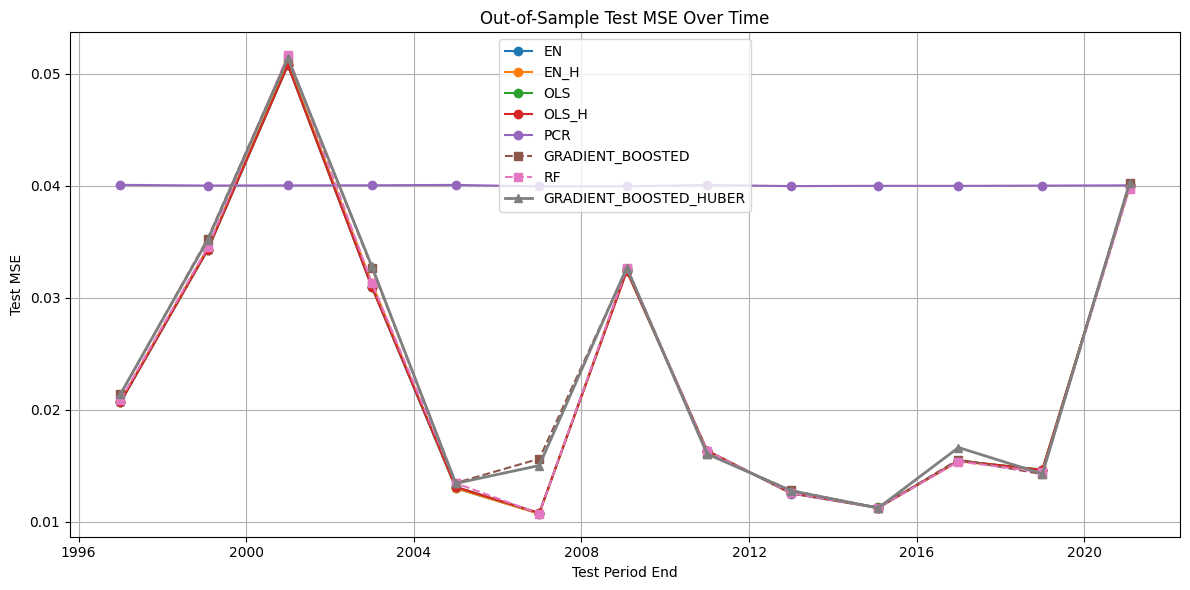

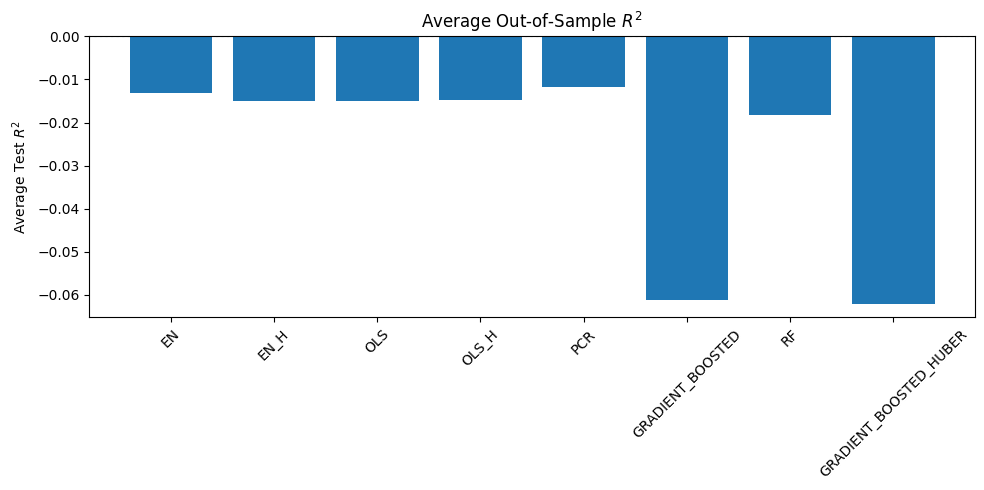

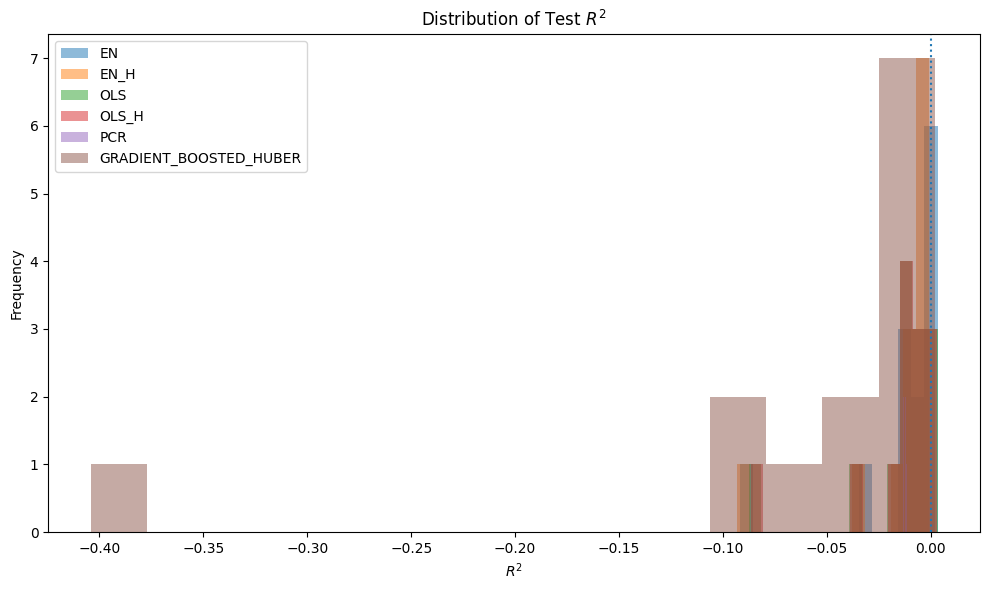

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# ASSUMPTIONS
# ============================================================
# tree_df   -> dataframe containing RF / boosted tree results
# linear_df -> dataframe containing linear model results
#
# Both already loaded into memory.
# ============================================================

# -----------------------------
# PREP
# -----------------------------
tree_df = tree.copy()
linear_df = linear.copy()

# Convert dates
for df in [tree_df, linear_df]:
    df["test_start"] = pd.to_datetime(df["test_start"])
    df["test_end"] = pd.to_datetime(df["test_end"])

# ============================================================
# 1. TEST R² OVER TIME
# ============================================================

plt.figure(figsize=(12, 6))

# Linear models
for method, grp in linear_df.groupby("method"):
    plt.plot(
        grp["test_end"],
        grp["r2_test"],
        marker="o",
        label=method
    )

# Tree models (standard metrics)
tree_regular = tree_df[tree_df["r2_test"].notna()]

for method, grp in tree_regular.groupby("method"):
    plt.plot(
        grp["test_end"],
        grp["r2_test"],
        marker="s",
        linestyle="--",
        label=method
    )

# Huber boosted tree metrics
tree_huber = tree_df[tree_df["r2_test_huber"].notna()]

if not tree_huber.empty:
    plt.plot(
        tree_huber["test_end"],
        tree_huber["r2_test_huber"],
        marker="^",
        linewidth=2,
        label="GRADIENT_BOOSTED_HUBER"
    )

plt.axhline(0, linestyle=":")
plt.title("Out-of-Sample Test $R^2$ Over Time")
plt.xlabel("Test Period End")
plt.ylabel("$R^2$")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 2. TEST MSE OVER TIME
# ============================================================

plt.figure(figsize=(12, 6))

# Linear models
for method, grp in linear_df.groupby("method"):
    plt.plot(
        grp["test_end"],
        grp["mse_test"],
        marker="o",
        label=method
    )

# Tree models
tree_regular = tree_df[tree_df["mse_test"].notna()]

for method, grp in tree_regular.groupby("method"):
    plt.plot(
        grp["test_end"],
        grp["mse_test"],
        marker="s",
        linestyle="--",
        label=method
    )

# Huber boosted tree
tree_huber = tree_df[tree_df["mse_test_huber"].notna()]

if not tree_huber.empty:
    plt.plot(
        tree_huber["test_end"],
        tree_huber["mse_test_huber"],
        marker="^",
        linewidth=2,
        label="GRADIENT_BOOSTED_HUBER"
    )

plt.title("Out-of-Sample Test MSE Over Time")
plt.xlabel("Test Period End")
plt.ylabel("Test MSE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ============================================================
# 3. AVERAGE R² BY MODEL
# ============================================================

summary = []

# Linear
for method, grp in linear_df.groupby("method"):
    summary.append({
        "model": method,
        "avg_r2": grp["r2_test"].mean()
    })

# Tree regular
for method, grp in tree_regular.groupby("method"):
    summary.append({
        "model": method,
        "avg_r2": grp["r2_test"].mean()
    })

# Huber boosted
if not tree_huber.empty:
    summary.append({
        "model": "GRADIENT_BOOSTED_HUBER",
        "avg_r2": tree_huber["r2_test_huber"].mean()
    })

summary_df = pd.DataFrame(summary)

plt.figure(figsize=(10, 5))
plt.bar(summary_df["model"], summary_df["avg_r2"])
plt.axhline(0, linestyle=":")
plt.title("Average Out-of-Sample $R^2$")
plt.ylabel("Average Test $R^2$")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 4. DISTRIBUTION OF TEST R²
# ============================================================

plt.figure(figsize=(10, 6))

# Linear models
for method, grp in linear_df.groupby("method"):
    plt.hist(
        grp["r2_test"],
        bins=15,
        alpha=0.5,
        label=method
    )

# Huber boosted
if not tree_huber.empty:
    plt.hist(
        tree_huber["r2_test_huber"],
        bins=15,
        alpha=0.5,
        label="GRADIENT_BOOSTED_HUBER"
    )

plt.axvline(0, linestyle=":")
plt.title("Distribution of Test $R^2$")
plt.xlabel("$R^2$")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()